In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [3]:
df = pd.read_csv(
    "../data/processed/tesla_stocks_cleaned.csv"
)

df.head()

,Date,Volume,Open,High,Low,Close
0,2014-12-08,138260571,14.7693,14.9907,14.1560,14.2907
1,2014-12-09,141405904,13.9560,14.5153,13.6180,14.4593
2,2014-12-10,109622540,14.2753,14.4513,13.8467,13.9893
3,2014-12-11,100266835,14.0353,14.3620,13.8820,13.9253
4,2014-12-12,107507556,13.6547,14.1120,13.6333,13.8000


In [4]:
data = df[['Close']]

print(data.head())

     Close
0  14.2907
1  14.4593
2  13.9893
3  13.9253
4  13.8000


In [5]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

print(scaled_data[:5])

[[0.01177022]
 [0.0121913 ]
 [0.01101745]
 [0.01085761]
 [0.01054467]]


In [6]:
X = []
y = []

sequence_length = 30

for i in range(sequence_length, len(scaled_data)):
    
    X.append(
        scaled_data[i-sequence_length:i]
    )
    
    y.append(
        scaled_data[i]
    )

X = np.array(X)
y = np.array(y)

In [7]:
print(X.shape)
print(y.shape)

(2487, 30, 1)
(2487, 1)


In [8]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [9]:
print(X_train.shape)
print(X_test.shape)

(1989, 30, 1)
(498, 30, 1)


In [10]:
model = Sequential()

model.add(
    LSTM(
        units=50,
        return_sequences=False,
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(Dense(1))

c:\Users\Maria\Documents\Projects\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0190 - val_loss: 0.0035
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.7184e-04 - val_loss: 0.0024
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.9073e-04 - val_loss: 0.0023
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.4905e-04 - val_loss: 0.0020
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.8117e-04 - val_loss: 0.0024
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.2574e-04 - val_loss: 0.0020
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.8156e-04 - val_loss: 0.0017
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 6.3207e-04 - val_loss: 0.0018
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.0980e-04 - val_loss: 0.0014
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.6369e-04 - val_loss: 0.0014
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.4638e-04 - val_loss: 0.0013
Epoch 12/20
63/63 ━━━━━

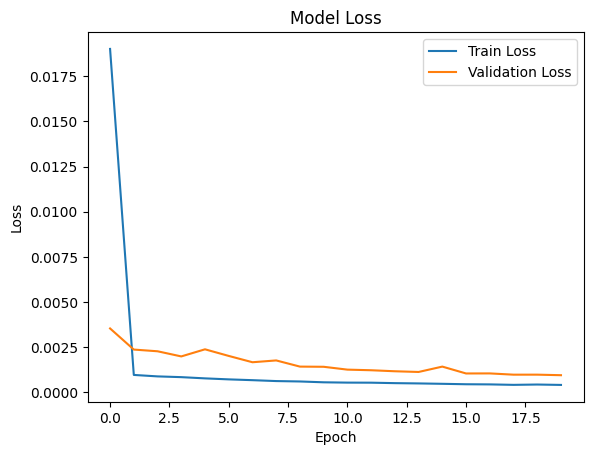

In [14]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train Loss', 'Validation Loss'])

plt.show()

In [15]:
y_pred = model.predict(X_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [16]:
y_pred = scaler.inverse_transform(y_pred)

y_test_actual = scaler.inverse_transform(y_test)

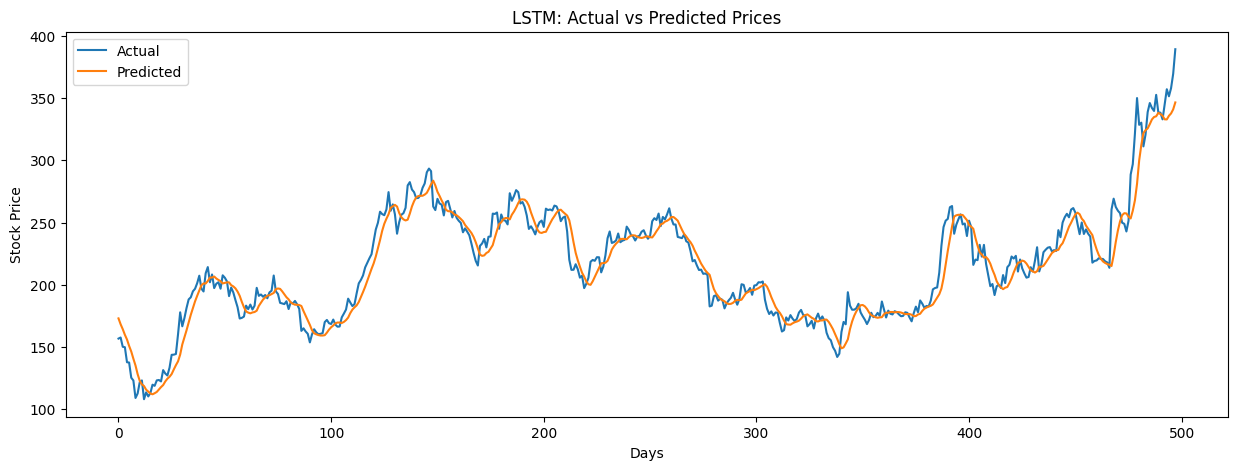

In [17]:
plt.figure(figsize=(15,5))

plt.plot(
    y_test_actual,
    label='Actual'
)

plt.plot(
    y_pred,
    label='Predicted'
)

plt.title('LSTM: Actual vs Predicted Prices')

plt.xlabel('Days')
plt.ylabel('Stock Price')

plt.legend()

plt.show()

In [18]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test_actual,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred
    )
)

r2 = r2_score(
    y_test_actual,
    y_pred
)

print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)
print("LSTM R2:", r2)

LSTM MAE: 9.071254846044333
LSTM RMSE: 12.384974749951626
LSTM R2: 0.9296789541652531


In [19]:
train_pred = model.predict(X_train)

train_pred = scaler.inverse_transform(train_pred)

y_train_actual = scaler.inverse_transform(y_train)

train_r2 = r2_score(
    y_train_actual,
    train_pred
)

test_r2 = r2_score(
    y_test_actual,
    y_pred
)

print("Train R2:", train_r2)
print("Test R2:", test_r2)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Train R2: 0.9943300932920929
Test R2: 0.9296789541652531


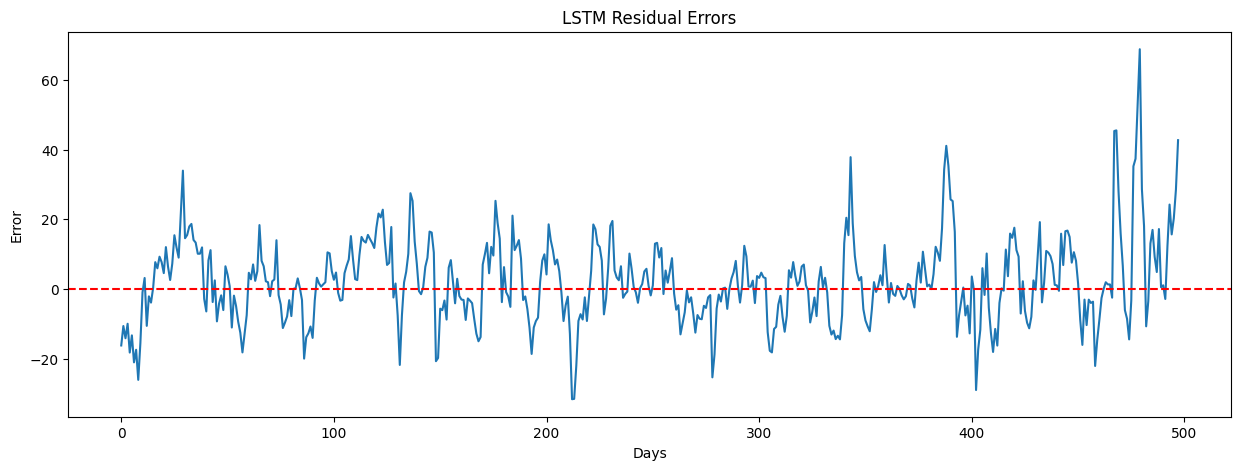

In [20]:
residuals = y_test_actual.flatten() - y_pred.flatten()

plt.figure(figsize=(15,5))

plt.plot(residuals)

plt.axhline(
    y=0,
    color='r',
    linestyle='--'
)

plt.title('LSTM Residual Errors')

plt.xlabel('Days')
plt.ylabel('Error')

plt.show()

In [21]:
model.save(
    "../models/lstm_tesla_stock_model.h5"
)